In [20]:
import numpy as np
import matplotlib.pyplot as plt

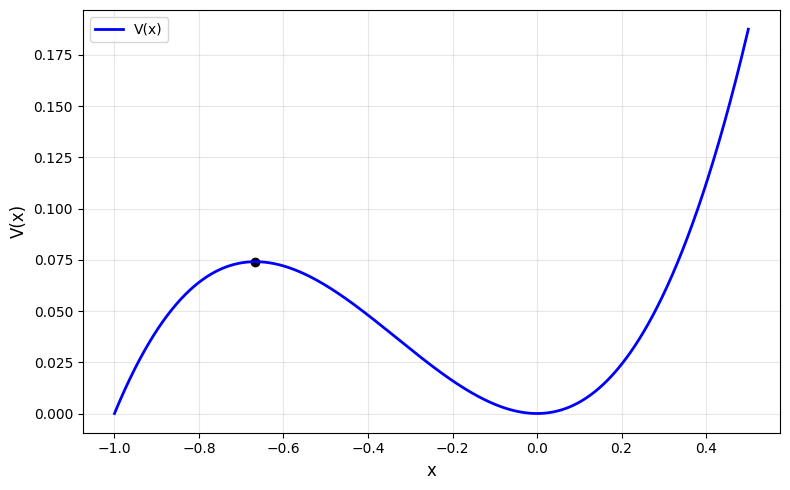

In [6]:
#params
m = 1
omega = 1
lam = 0.5

def v(x):
    return 0.5*m*omega*omega*x*x + lam*x*x*x
x0 = -m*omega*omega/(3*lam)
# Plot potential
plt.figure(figsize=(8, 5))
v0 = v(x0)
plt.plot(x0, v0, 'ko')
x_plot = np.linspace(-1, 0.5, 1000)
V_plot = v(x_plot)
plt.plot(x_plot, V_plot, 'b-', linewidth=2, label='V(x)')
plt.xlabel('x', fontsize=12)
plt.ylabel('V(x)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Analytical Part (a) and (b)

Given
$$
V(x)=\frac{1}{2}m\omega^2x^2+\lambda x^3,\quad x_0=-\frac{m\omega^2}{3\lambda},\quad \tau=\omega t,\quad \xi=\frac{x}{|x_0|}.
$$

Since $x=|x_0|\xi$,
$$
\dot x=|x_0|\omega\xi',\quad \ddot x=|x_0|\omega^2\xi''.
$$

Equation of motion in $x$:
$$
m\ddot x=-\frac{dV}{dx}=-(m\omega^2x+3\lambda x^2).
$$

Substitute $x=|x_0|\xi$, divide by $m\omega^2|x_0|$:
$$
\xi''=-\xi-\frac{3\lambda|x_0|}{m\omega^2}\xi^2.
$$

Using $|x_0|=\frac{m\omega^2}{3\lambda}$ gives
$$
\boxed{\xi''=-\xi+\xi^2}.
$$

Dimensionless potential (up to scale):
$$
\boxed{V(\xi)=\frac{1}{2}\xi^2-\frac{1}{3}\xi^3},
$$
so the dimensionless energy is
$$
\boxed{E=\frac{1}{2}(\xi')^2+V(\xi)}.
$$

Barrier check:
$$
\frac{dV}{d\xi}=\xi-\xi^2=\xi(1-\xi)=0\Rightarrow \xi=0,1.
$$
At $\xi=1$:
$$
V(1)=\frac{1}{2}-\frac{1}{3}=\frac{1}{6}.
$$
Hence escape requires
$$
\boxed{E\geq \frac{1}{6}}.
$$

For small amplitude $A\ll 1$:
$$
\omega_{\mathrm{eff}}=1-\frac{5A^2}{12}.
$$
For $A=0.3$,
$$
\omega_{\mathrm{eff}}=1-\frac{5(0.3)^2}{12}=0.9625.
$$
The cubic term makes the well asymmetric, effectively weakening restoring force over part of the cycle, so frequency decreases.

In [21]:
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller(my_method, fn, y_ini, N, xs, h):
    """
    Uses a general-purpose integrator.
    method is typically `euler`, `midpoint`, or `rk4`, but can be another function with signature: method(fn, x, y, h).

    Returns an array of solutions (ys).
    """
    E_drift = 0
    y = np.array(y_ini, dtype=np.float64)
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = my_method(fn, x, y, h)
        if abs(y_ini[0] - y[0]) > 1.0e-4:
            E_drift += 1
    if E_drift != 0:
        print("E Drift Detected")
    return ys

def caller_stop(my_method, fn, y_ini, N, xs, h, stop_xi=5.0):
    """
    Same as caller, but stops once xi crosses stop_xi.
    Returns trimmed arrays: ys_used, ts_used.
    """
    y = np.array(y_ini, dtype=np.float64)
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        # Stop once xi has crossed the requested threshold.
        if y[0] > stop_xi:
            return ys[: i + 1], xs[: i + 1]
        y = my_method(fn, x, y, h)
    return ys, xs

def V_dimless(xi):
    return 0.5 * xi**2 - (1.0 / 3.0) * xi**3

def E_dimless(state):
    xi = state[..., 0]
    xidot = state[..., 1]
    return 0.5 * xidot**2 + V_dimless(xi)

In [22]:
# Define the function g(t, y) returns 
def g_ty(t, y):
    return np.asarray([y[1], -y[0] + y[0]*y[0]])

# Parameters
h = 1.0e-2 # dτ = 0.01
t0 = 0.0
tf = 50.0

N = int((tf-t0)/h + 1)

In [23]:
# (a) and (b) checks
print("Dimensionless equation: xi'' = -xi + xi^2")
print("Dimensionless potential: V(xi) = 0.5*xi^2 - (1/3)*xi^3")
print("Barrier: xi = 1, V(1) =", V_dimless(1.0), "(expected 1/6 =", 1.0 / 6.0, ")")

A = 0.3
omega_eff = 1.0 - 5.0 * A**2 / 12.0
print(f"For A = {A}, omega_eff = {omega_eff:.6f}")
print("Cubic term lowers frequency because positive xi feels a weaker restoring force in this asymmetric well.")

Dimensionless equation: xi'' = -xi + xi^2
Dimensionless potential: V(xi) = 0.5*xi^2 - (1/3)*xi^3
Barrier: xi = 1, V(1) = 0.16666666666666669 (expected 1/6 = 0.16666666666666666 )
For A = 0.3, omega_eff = 0.962500
Cubic term lowers frequency because positive xi feels a weaker restoring force in this asymmetric well.


In [24]:
# (c) RK4: cases A and B to tau = 50
h = 1.0e-2
t0 = 0.0
tf_ab = 50.0

def g_ty(_t, y):
    return np.asarray([y[1], -y[0] + y[0] * y[0]], dtype=np.float64)

N_ab = int((tf_ab - t0) / h) + 1
ts_ab = np.arange(t0, t0 + N_ab * h, h)

cases = {
    "A": np.array([0.3, 0.0], dtype=np.float64),
    "B": np.array([0.9, 0.0], dtype=np.float64),
}

results = {}
for label, y0 in cases.items():
    ys = caller(rk4, g_ty, y0, N_ab, ts_ab, h)
    E = E_dimless(ys)
    dE = E - E[0]
    max_drift = float(np.max(np.abs(dE)))
    results[label] = {"ts": ts_ab, "ys": ys, "E": E, "dE": dE, "max_drift": max_drift}
    print(f"Case {label}: E(0) = {E[0]:.8f}, max |E(t)-E(0)| = {max_drift:.3e}")

tol = 1.0e-4
print(f"Energy conservation check (A,B): max drift < {tol:.1e}")
print("A:", results["A"]["max_drift"] < tol, "B:", results["B"]["max_drift"] < tol)

E Drift Detected
Case A: E(0) = 0.03600000, max |E(t)-E(0)| = 3.140e-12
E Drift Detected
Case B: E(0) = 0.16200000, max |E(t)-E(0)| = 2.832e-11
Energy conservation check (A,B): max drift < 1.0e-04
A: True B: True


Case C crosses xi=1 at tau = 1.6600


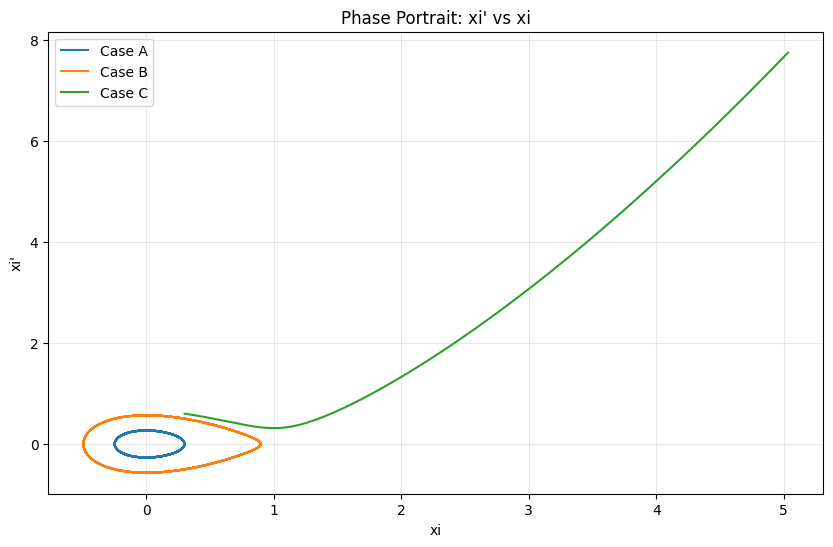

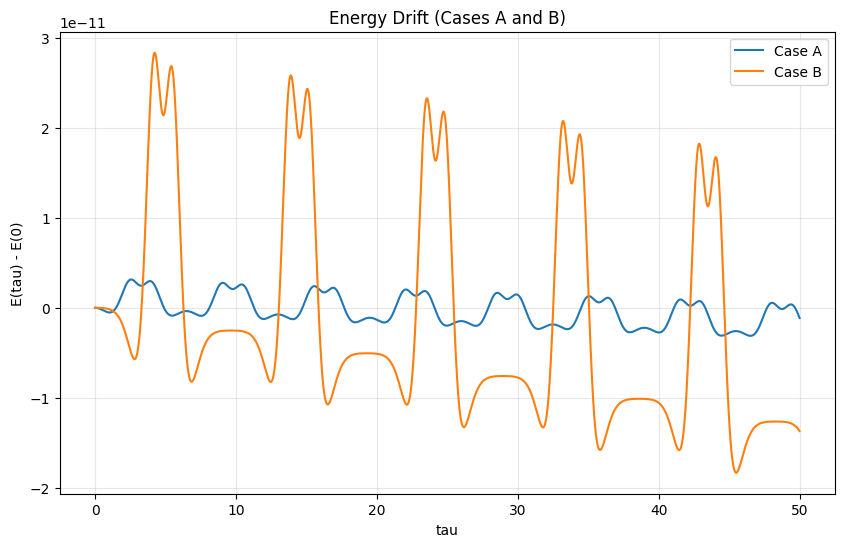

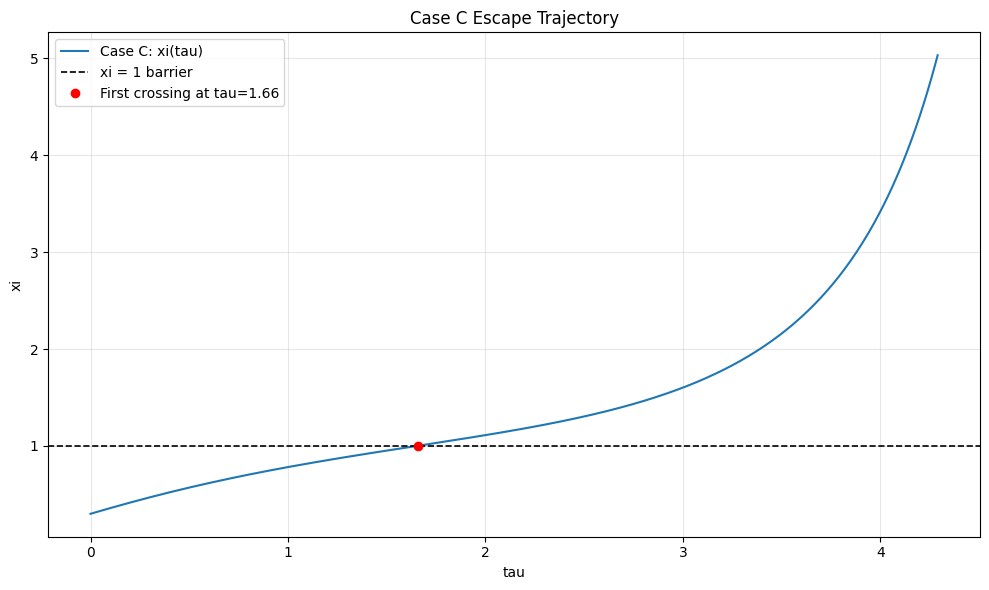

In [25]:
# (c) case C and (d) plots
tf_c = 100.0
N_c = int((tf_c - t0) / h) + 1
ts_c_full = np.arange(t0, t0 + N_c * h, h)

y0_c = np.array([0.3, 0.6], dtype=np.float64)
ys_c, ts_c = caller_stop(rk4, g_ty, y0_c, N_c, ts_c_full, h, stop_xi=5.0)

E_c = E_dimless(ys_c)
dE_c = E_c - E_c[0]

# (d)(i) Phase portrait: xi' vs xi for all cases
plt.figure(figsize=(10, 6))
for label in ["A", "B"]:
    ys = results[label]["ys"]
    plt.plot(ys[:, 0], ys[:, 1], label=f"Case {label}")
plt.plot(ys_c[:, 0], ys_c[:, 1], label="Case C")
plt.xlabel("xi")
plt.ylabel("xi'")
plt.title("Phase Portrait: xi' vs xi")
plt.grid(alpha=0.3)
plt.legend()

# (d)(ii) Energy drift for A and B on same panel
plt.figure(figsize=(10, 6))
plt.plot(results["A"]["ts"], results["A"]["dE"], label="Case A")
plt.plot(results["B"]["ts"], results["B"]["dE"], label="Case B")
plt.xlabel("tau")
plt.ylabel("E(tau) - E(0)")
plt.title("Energy Drift (Cases A and B)")
plt.grid(alpha=0.3)
plt.legend()

# (d)(iii) Escape plot for C: xi(tau), mark crossing xi = 1
cross_idx = np.where(ys_c[:, 0] >= 1.0)[0]
plt.figure(figsize=(10, 6))
plt.plot(ts_c, ys_c[:, 0], label="Case C: xi(tau)")
plt.axhline(1.0, color="k", linestyle="--", linewidth=1.2, label="xi = 1 barrier")
if len(cross_idx) > 0:
    i1 = int(cross_idx[0])
    plt.plot(ts_c[i1], ys_c[i1, 0], "ro", label=f"First crossing at tau={ts_c[i1]:.2f}")
    print(f"Case C crosses xi=1 at tau = {ts_c[i1]:.4f}")
else:
    print("Case C did not cross xi = 1 within simulation window.")
plt.xlabel("tau")
plt.ylabel("xi")
plt.title("Case C Escape Trajectory")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()